In [3]:
import pickle
import matplotlib.pyplot as plt

import torchaudio
import torch

In [4]:
# Load pickle file
with open('sample_0.data', 'rb') as f:
    data = pickle.load(f)

In [5]:
print(data[0])

{'id': 845, 'num_samples': 270720, 'path': None, 'audio': {'path': 'train/14699537390019605585.wav', 'array': array([ 0.        ,  0.        ,  0.        , ..., -0.00014174,
       -0.00013965, -0.00014967], shape=(270720,)), 'sampling_rate': 16000}, 'transcription': 'जरी ते आधुनिक घटनांपासून खूप दूर असले तरी बरेच लोक कदाचित त्यास स्प्रे पेंट वापरून सार्वजनिक आणि खाजगी मालमत्तेचा विध्वंस करणाऱ्या तरुणांशी जोडतात', 'raw_transcription': 'जरी ते आधुनिक घटनांपासून खूप दूर असले, तरी बरेच लोक कदाचित त्यास स्प्रे पेंट वापरून सार्वजनिक आणि खाजगी मालमत्तेचा विध्वंस करणाऱ्या तरुणांशी जोडतात.', 'gender': 0, 'lang_id': 0, 'language': 'Afrikaans', 'lang_group_id': 3}


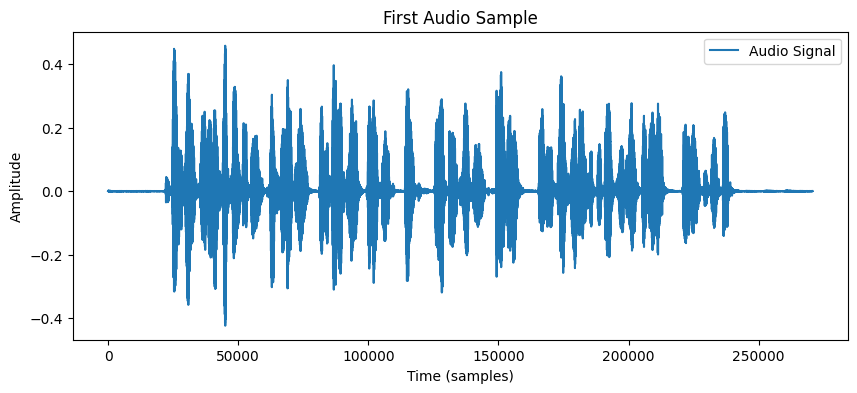

In [6]:
# Visualize first audio sample
wav = torch.tensor(data[0]["audio"]["array"], dtype=torch.float32)
plt.figure(figsize=(10, 4))
plt.plot(wav.numpy(), label='Audio Signal')
plt.title('First Audio Sample')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

In [ ]:
# Play the first audio sample
import sounddevice as sd
sd.play(wav.numpy(), samplerate=16000)
sd.wait()

In [13]:
# Log-mel conversion

TARGET_SR = 16000 # Input is 16kHz
N_MELS = 80 # Convert to 80-dim log-mel spectrograms

mel = torchaudio.transforms.MelSpectrogram(
    sample_rate=TARGET_SR,
    n_fft=400,
    hop_length=160,
    n_mels=N_MELS,
)

amp_to_db = torchaudio.transforms.AmplitudeToDB()

def waveform_to_logmel(waveform: torch.Tensor) -> torch.Tensor:
    """
    waveform: [1, N] (mono)
    returns: [T, F] where F=80
    """
    m = mel(waveform)          # [1, F, T]
    m = amp_to_db(m)           # log-mel
    m = m.squeeze(0).transpose(0, 1).contiguous()  # -> [T, F]
    return m

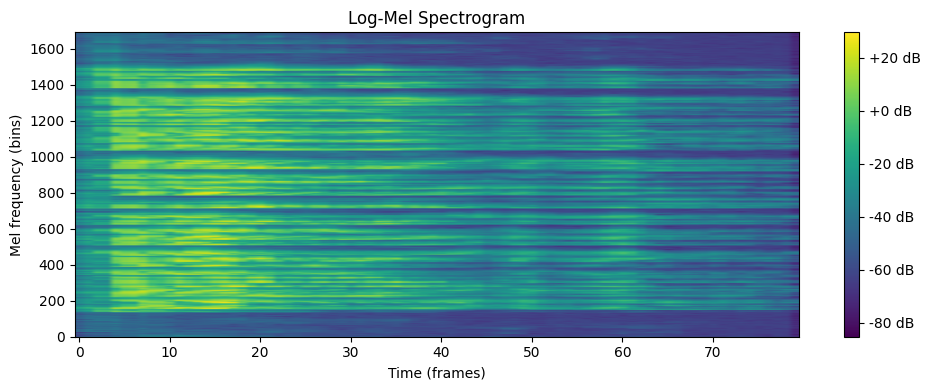

In [14]:
logmel_tensor = waveform_to_logmel(wav.unsqueeze(0))  # Add batch dimension

# Visualize log-mel spectrogram
plt.figure(figsize=(10, 4))
plt.imshow(logmel_tensor.squeeze(0).detach().numpy(), aspect='auto', origin='lower')
plt.colorbar(format='%+2.0f dB')
plt.xlabel('Time (frames)')
plt.ylabel('Mel frequency (bins)')
plt.title('Log-Mel Spectrogram')
plt.tight_layout()
plt.show()

In [8]:
from collections import OrderedDict

_FLEURS_LANG = sorted(["af_za", "am_et", "ar_eg", "as_in", "ast_es", "az_az", "be_by", "bn_in", "bs_ba", "ca_es", "ceb_ph", "cmn_hans_cn", "yue_hant_hk", "cs_cz", "cy_gb", "da_dk", "de_de", "el_gr", "en_us", "es_419", "et_ee", "fa_ir", "ff_sn", "fi_fi", "fil_ph", "fr_fr", "ga_ie", "gl_es", "gu_in", "ha_ng", "he_il", "hi_in", "hr_hr", "hu_hu", "hy_am", "id_id", "ig_ng", "is_is", "it_it", "ja_jp", "jv_id", "ka_ge", "kam_ke", "kea_cv", "kk_kz", "km_kh", "kn_in", "ko_kr", "ckb_iq", "ky_kg", "lb_lu", "lg_ug", "ln_cd", "lo_la", "lt_lt", "luo_ke", "lv_lv", "mi_nz", "mk_mk", "ml_in", "mn_mn", "mr_in", "ms_my", "mt_mt", "my_mm", "nb_no", "ne_np", "nl_nl", "nso_za", "ny_mw", "oc_fr", "om_et", "or_in", "pa_in", "pl_pl", "ps_af", "pt_br", "ro_ro", "ru_ru", "bg_bg", "sd_in", "sk_sk", "sl_si", "sn_zw", "so_so", "sr_rs", "sv_se", "sw_ke", "ta_in", "te_in", "tg_tj", "th_th", "tr_tr", "uk_ua", "umb_ao", "ur_pk", "uz_uz", "vi_vn", "wo_sn", "xh_za", "yo_ng", "zu_za"])
_FLEURS_LANG_TO_ID = OrderedDict([("Afrikaans", "af"), ("Amharic", "am"), ("Arabic", "ar"), ("Armenian", "hy"), ("Assamese", "as"), ("Asturian", "ast"), ("Azerbaijani", "az"), ("Belarusian", "be"), ("Bengali", "bn"), ("Bosnian", "bs"), ("Bulgarian", "bg"), ("Burmese", "my"), ("Catalan", "ca"), ("Cebuano", "ceb"), ("Mandarin Chinese", "cmn_hans"), ("Cantonese Chinese", "yue_hant"), ("Croatian", "hr"), ("Czech", "cs"), ("Danish", "da"), ("Dutch", "nl"), ("English", "en"), ("Estonian", "et"), ("Filipino", "fil"), ("Finnish", "fi"), ("French", "fr"), ("Fula", "ff"), ("Galician", "gl"), ("Ganda", "lg"), ("Georgian", "ka"), ("German", "de"), ("Greek", "el"), ("Gujarati", "gu"), ("Hausa", "ha"), ("Hebrew", "he"), ("Hindi", "hi"), ("Hungarian", "hu"), ("Icelandic", "is"), ("Igbo", "ig"), ("Indonesian", "id"), ("Irish", "ga"), ("Italian", "it"), ("Japanese", "ja"), ("Javanese", "jv"), ("Kabuverdianu", "kea"), ("Kamba", "kam"), ("Kannada", "kn"), ("Kazakh", "kk"), ("Khmer", "km"), ("Korean", "ko"), ("Kyrgyz", "ky"), ("Lao", "lo"), ("Latvian", "lv"), ("Lingala", "ln"), ("Lithuanian", "lt"), ("Luo", "luo"), ("Luxembourgish", "lb"), ("Macedonian", "mk"), ("Malay", "ms"), ("Malayalam", "ml"), ("Maltese", "mt"), ("Maori", "mi"), ("Marathi", "mr"), ("Mongolian", "mn"), ("Nepali", "ne"), ("Northern-Sotho", "nso"), ("Norwegian", "nb"), ("Nyanja", "ny"), ("Occitan", "oc"), ("Oriya", "or"), ("Oromo", "om"), ("Pashto", "ps"), ("Persian", "fa"), ("Polish", "pl"), ("Portuguese", "pt"), ("Punjabi", "pa"), ("Romanian", "ro"), ("Russian", "ru"), ("Serbian", "sr"), ("Shona", "sn"), ("Sindhi", "sd"), ("Slovak", "sk"), ("Slovenian", "sl"), ("Somali", "so"), ("Sorani-Kurdish", "ckb"), ("Spanish", "es"), ("Swahili", "sw"), ("Swedish", "sv"), ("Tajik", "tg"), ("Tamil", "ta"), ("Telugu", "te"), ("Thai", "th"), ("Turkish", "tr"), ("Ukrainian", "uk"), ("Umbundu", "umb"), ("Urdu", "ur"), ("Uzbek", "uz"), ("Vietnamese", "vi"), ("Welsh", "cy"), ("Wolof", "wo"), ("Xhosa", "xh"), ("Yoruba", "yo"), ("Zulu", "zu")])
_FLEURS_LANG_SHORT_TO_LONG = {v: k for k, v in _FLEURS_LANG_TO_ID.items()}
_FLEURS_LONG_TO_LANG = {_FLEURS_LANG_SHORT_TO_LONG["_".join(k.split("_")[:-1]) or k]: k for k in _FLEURS_LANG}
_FLEURS_GROUP_TO_LONG = OrderedDict({
    "western_european_we": ["Asturian", "Bosnian", "Catalan", "Croatian", "Danish", "Dutch", "English", "Finnish", "French", "Galician", "German", "Greek", "Hungarian", "Icelandic", "Irish", "Italian", "Kabuverdianu", "Luxembourgish", "Maltese", "Norwegian", "Occitan", "Portuguese", "Spanish", "Swedish", "Welsh"],
    "eastern_european_ee": ["Armenian", "Belarusian", "Bulgarian", "Czech", "Estonian", "Georgian", "Latvian", "Lithuanian", "Macedonian", "Polish", "Romanian", "Russian", "Serbian", "Slovak", "Slovenian", "Ukrainian"],
    "central_asia_middle_north_african_cmn": ["Arabic", "Azerbaijani", "Hebrew", "Kazakh", "Kyrgyz", "Mongolian", "Pashto", "Persian", "Sorani-Kurdish", "Tajik", "Turkish", "Uzbek"],
    "sub_saharan_african_ssa": ["Afrikaans", "Amharic", "Fula", "Ganda", "Hausa", "Igbo", "Kamba", "Lingala", "Luo", "Northern-Sotho", "Nyanja", "Oromo", "Shona", "Somali", "Swahili", "Umbundu", "Wolof", "Xhosa", "Yoruba", "Zulu"],
    "south_asian_sa": ["Assamese", "Bengali", "Gujarati", "Hindi", "Kannada", "Malayalam", "Marathi", "Nepali", "Oriya", "Punjabi", "Sindhi", "Tamil", "Telugu", "Urdu"],
    "south_east_asian_sea": ["Burmese", "Cebuano", "Filipino", "Indonesian", "Javanese", "Khmer", "Lao", "Malay", "Maori", "Thai", "Vietnamese"],
    "chinese_japanase_korean_cjk": ["Mandarin Chinese", "Cantonese Chinese", "Japanese", "Korean"],
})

# Get ids of all eastern european languages
eastern_ids = [_FLEURS_LONG_TO_LANG[lang] for lang in _FLEURS_GROUP_TO_LONG["eastern_european_ee"]]
southeast_asian_ids = [_FLEURS_LONG_TO_LANG[lang] for lang in _FLEURS_GROUP_TO_LONG["south_east_asian_sea"]]
print(eastern_ids)
# print(_FLEURS_LONG_TO_LANG)

['hy_am', 'be_by', 'bg_bg', 'cs_cz', 'et_ee', 'ka_ge', 'lv_lv', 'lt_lt', 'mk_mk', 'pl_pl', 'ro_ro', 'ru_ru', 'sr_rs', 'sk_sk', 'sl_si', 'uk_ua']


In [9]:
southeast_asian_lang_ids = [i for i, lang in enumerate(_FLEURS_LANG) if lang in southeast_asian_ids]
print(southeast_asian_lang_ids)

[11, 25, 36, 41, 46, 53, 57, 62, 64, 90, 96]


In [4]:
from datasets import load_dataset

ids = ['hy_am', 'be_by', 'bg_bg', 'cs_cz', 'et_ee', 'ka_ge', 'lv_lv', 'lt_lt', 'mk_mk', 'pl_pl', 'ro_ro', 'ru_ru', 'sr_rs', 'sk_sk', 'sl_si', 'uk_ua']
lang_ids = [35, 6, 7, 14, 21, 42, 56, 54, 58, 74, 77, 78, 84, 80, 81, 92]

for id in ids:
    fleurs_asr = load_dataset("google/fleurs", id, split="train", streaming=True)
    # Get first example
    ex = next(iter(fleurs_asr))
    first_example = ex["lang_id"]
    print(first_example)
    lang_ids.append(first_example)
print(lang_ids)

35
6
7
14
21
42
56
54
58
74
77
78
84
80
81
92
[35, 6, 7, 14, 21, 42, 56, 54, 58, 74, 77, 78, 84, 80, 81, 92]


In [6]:
len([35, 6, 7, 14, 21, 42, 56, 54, 58, 74, 77, 78, 84, 80, 81, 92])

16